In [9]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("shenba/time-series-datasets")
beer = pd.read_csv(path + '/monthly-beer-production-in-austr.csv')

In [8]:
beer.columns = ['Month', 'Production']
beer['Month'] = pd.to_datetime(beer['Month'])
beer = beer.set_index('Month').sort_index()
beer = beer.asfreq('MS')
beer.head()

,Production
Month,
1956-01-01,93.2
1956-02-01,96.0
1956-03-01,95.2
1956-04-01,77.1
1956-05-01,70.9


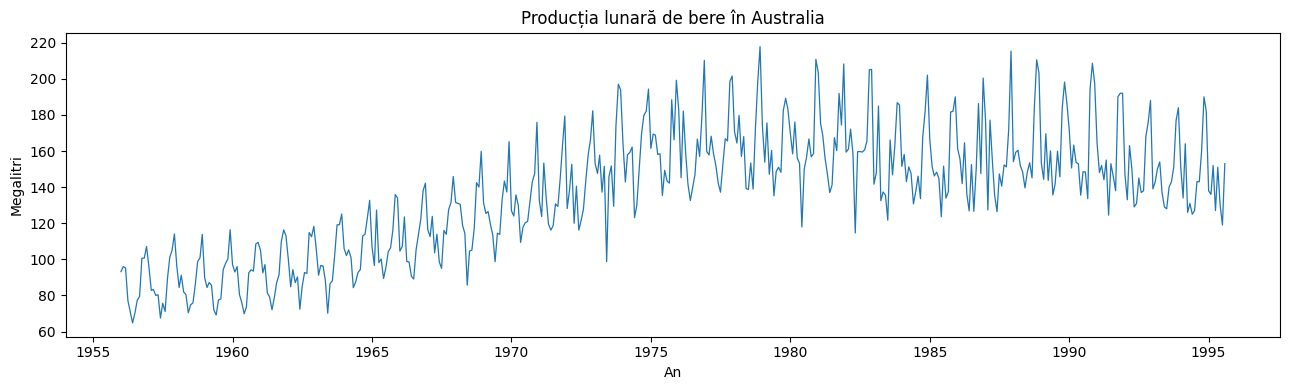

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(beer.index, beer['Production'], lw=0.9)
ax.set_title('Productia lunara de bere in Australia')
ax.set_ylabel('Megalitri'); ax.set_xlabel('An')
plt.tight_layout(); plt.show()

## Interpolare

In [15]:
beer_gaps = beer.copy()
rng = np.random.default_rng(42)
missing_idx = rng.choice(beer_gaps.index[12:-12], size=15, replace=False)
beer_gaps.loc[missing_idx, 'Production'] = np.nan

In [19]:
interp = pd.DataFrame(index=beer_gaps.index)
interp['liniara']  = beer_gaps['Production'].interpolate(method='linear')
interp['spline3']  = beer_gaps['Production'].interpolate(method='spline', order=3)

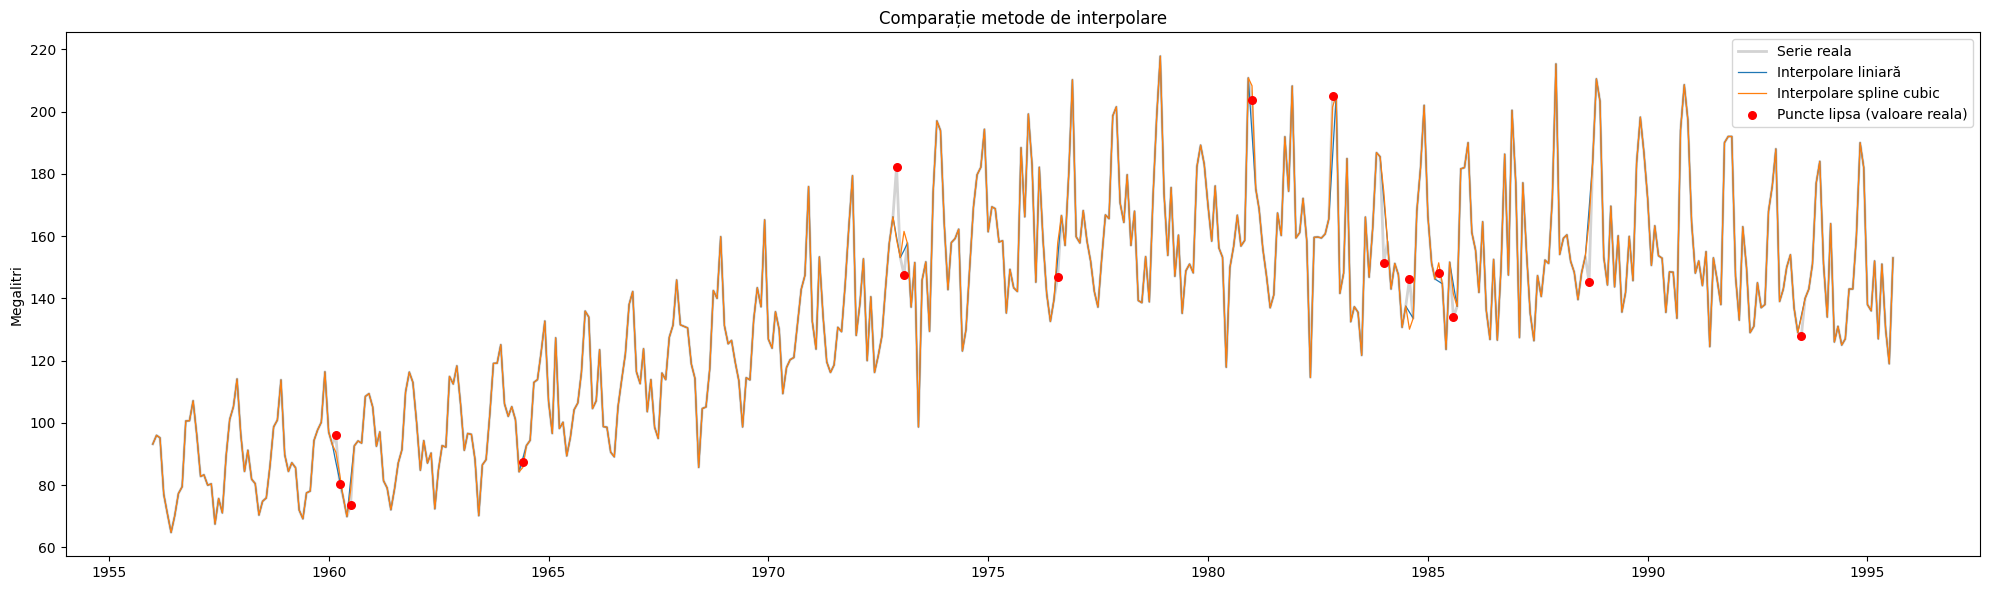

In [20]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(beer.index, beer['Production'], color='lightgray', lw=2, label='Serie reala')
ax.plot(interp.index, interp['liniara'], lw=0.9, label='Interpolare liniară')
ax.plot(interp.index, interp['spline3'], lw=0.9, label='Interpolare spline cubic')
ax.scatter(missing_idx, beer.loc[missing_idx, 'Production'],
           color='red', zorder=5, s=30, label='Puncte lipsa (valoare reala)')
ax.set_title('Comparație metode de interpolare')
ax.set_ylabel('Megalitri'); ax.legend()
plt.tight_layout(); plt.show()

## Agregare

In [22]:
# Resampling la nivel trimestrial si anual
trimestrial = beer['Production'].resample('QS').sum()   # productie totala pe trimestru
anual_suma  = beer['Production'].resample('YS').sum()    # productie totala pe an
anual_medie = beer['Production'].resample('YS').mean()   # productie medie lunara pe an

print(trimestrial.head(), "\n")
print(anual_suma.head())

Month
1956-01-01    284.4
1956-04-01    212.8
1956-07-01    226.9
1956-10-01    308.4
1957-01-01    262.0
Freq: QS-JAN, Name: Production, dtype: float64 

Month
1956-01-01    1032.5
1957-01-01    1046.4
1958-01-01    1055.1
1959-01-01    1052.4
1960-01-01    1084.4
Freq: YS-JAN, Name: Production, dtype: float64


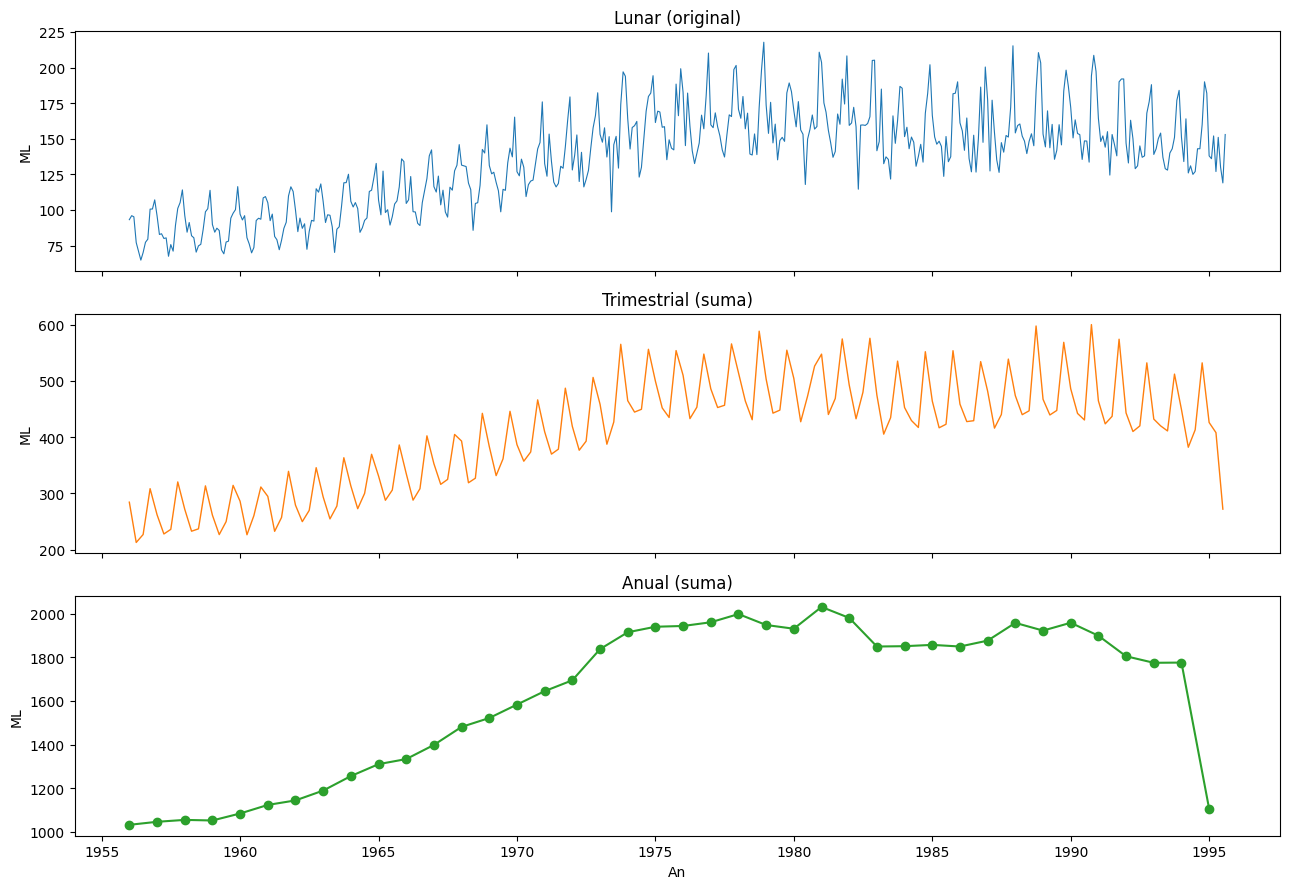

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(beer.index, beer['Production'], lw=0.8)
axes[0].set_title('Lunar (original)'); axes[0].set_ylabel('ML')

axes[1].plot(trimestrial.index, trimestrial.values, lw=1, color='tab:orange')
axes[1].set_title('Trimestrial (suma)'); axes[1].set_ylabel('ML')

axes[2].plot(anual_suma.index, anual_suma.values, marker='o', color='tab:green')
axes[2].set_title('Anual (suma)'); axes[2].set_ylabel('ML'); axes[2].set_xlabel('An')

plt.tight_layout(); plt.show()

## Diferentiere

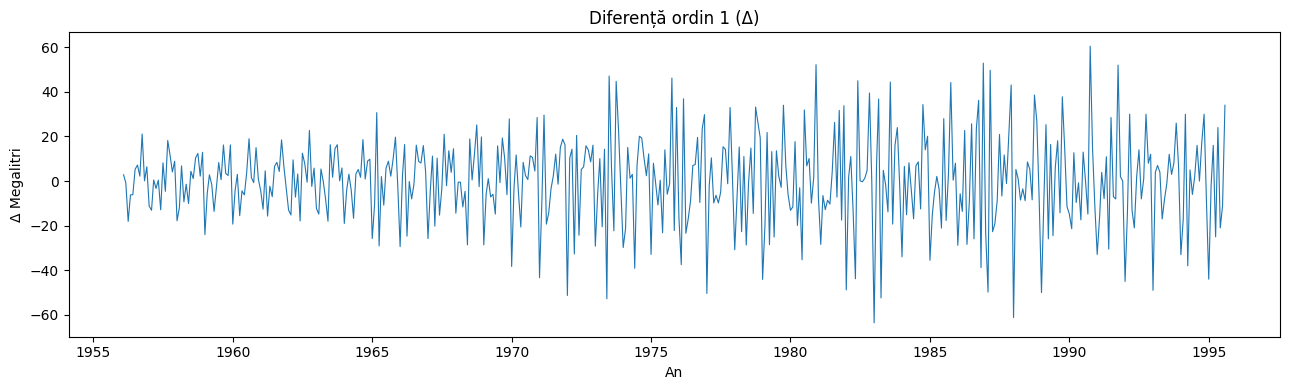

In [41]:
# Diferențiere de ordinul 1 (elimină trendul)
diff1 = beer['Production'].diff()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(diff1.index, diff1, lw=0.8, color='tab:blue')
ax.set_title('Diferență ordin 1 (Δ)')
ax.set_ylabel('Δ Megalitri'); ax.set_xlabel('An')
plt.tight_layout(); plt.show()

## Descompunere

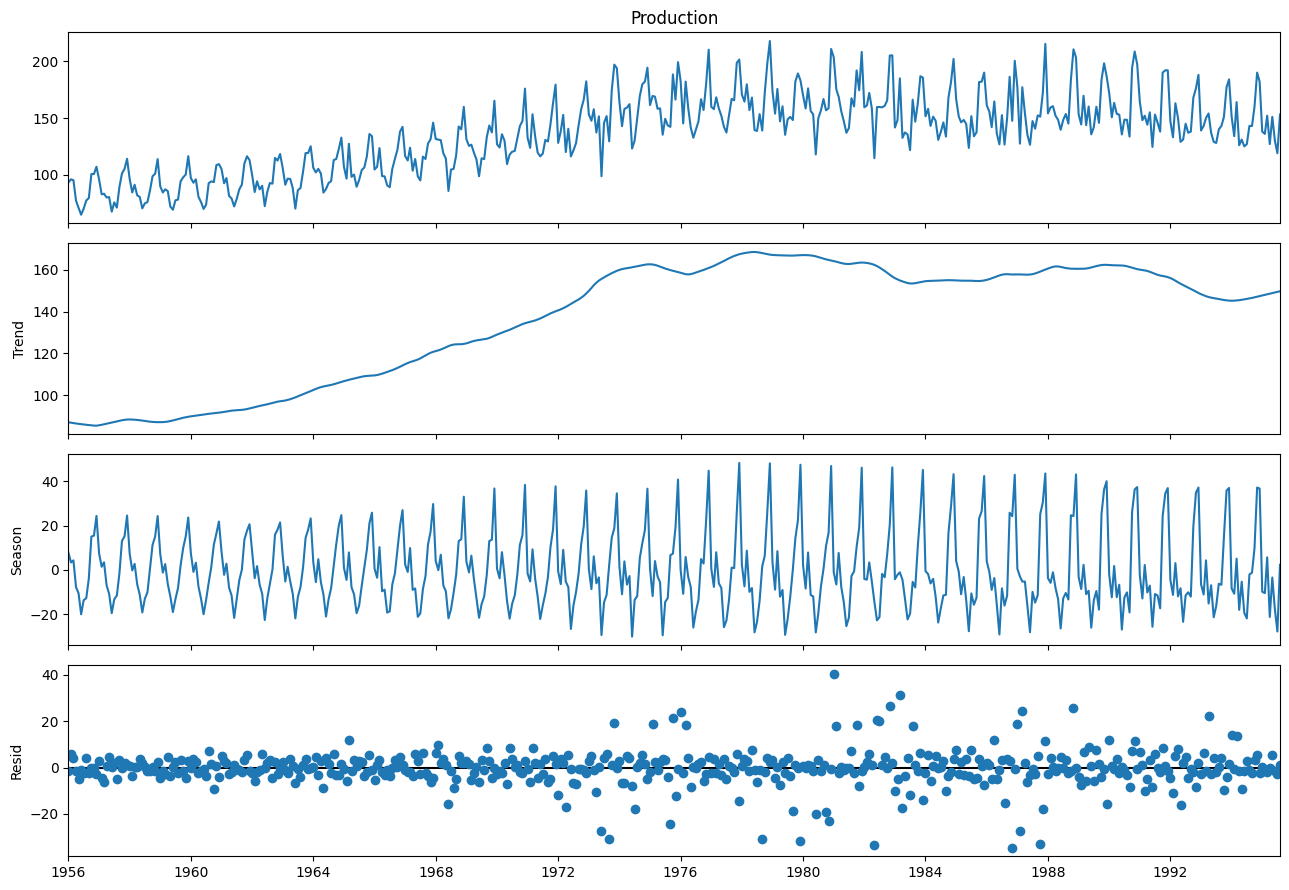

In [29]:
from statsmodels.tsa.seasonal import STL

stl = STL(beer['Production'], period=12, robust=True)
res_stl = stl.fit()

fig = res_stl.plot()
fig.set_size_inches(13, 9)
plt.tight_layout(); plt.show()

In [32]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.8 MB/s eta 0:00:00


In [33]:
from pyts.decomposition import SingularSpectrumAnalysis

serie = beer['Production'].values
X = serie.reshape(1, -1)
L = 60 # Numar componente
ssa_full = SingularSpectrumAnalysis(window_size=L, groups=None)
componente = ssa_full.fit_transform(X)[0]   # shape: (n_componente, n_timestamps)


Număr de componente elementare: 60


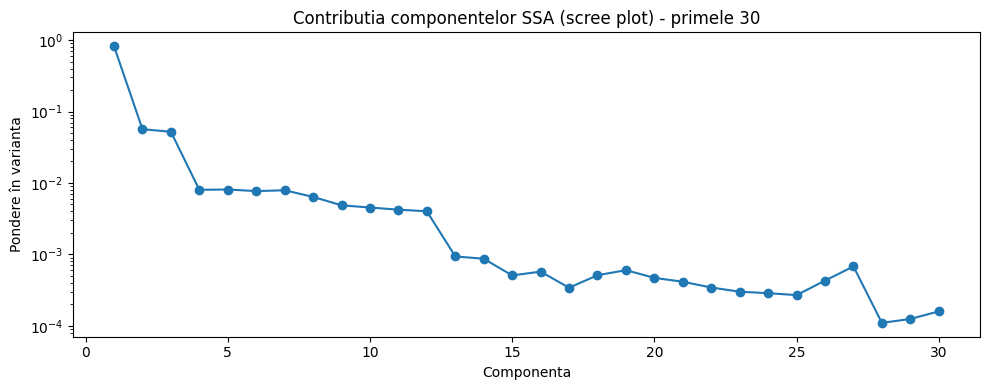

Componenta 0: 82.30%
Componenta 1:  5.66%
Componenta 2:  5.21%
Componenta 3:  0.80%
Componenta 4:  0.81%
Componenta 5:  0.77%
Componenta 6:  0.79%
Componenta 7:  0.64%


In [38]:
var_comp = componente.var(axis=1)
contrib = var_comp / var_comp.sum()

fig, ax = plt.subplots(figsize=(10, 4))
n_show = min(30, len(contrib))
ax.plot(range(1, n_show + 1), contrib[:n_show], 'o-')
ax.set_title('Contributia componentelor SSA (scree plot) - primele 30')
ax.set_xlabel('Componenta'); ax.set_ylabel('Pondere în varianta')
ax.set_yscale('log'); plt.tight_layout(); plt.show()

for i in range(min(8, len(contrib))):
    print(f"Componenta {i}: {contrib[i]*100:5.2f}%")

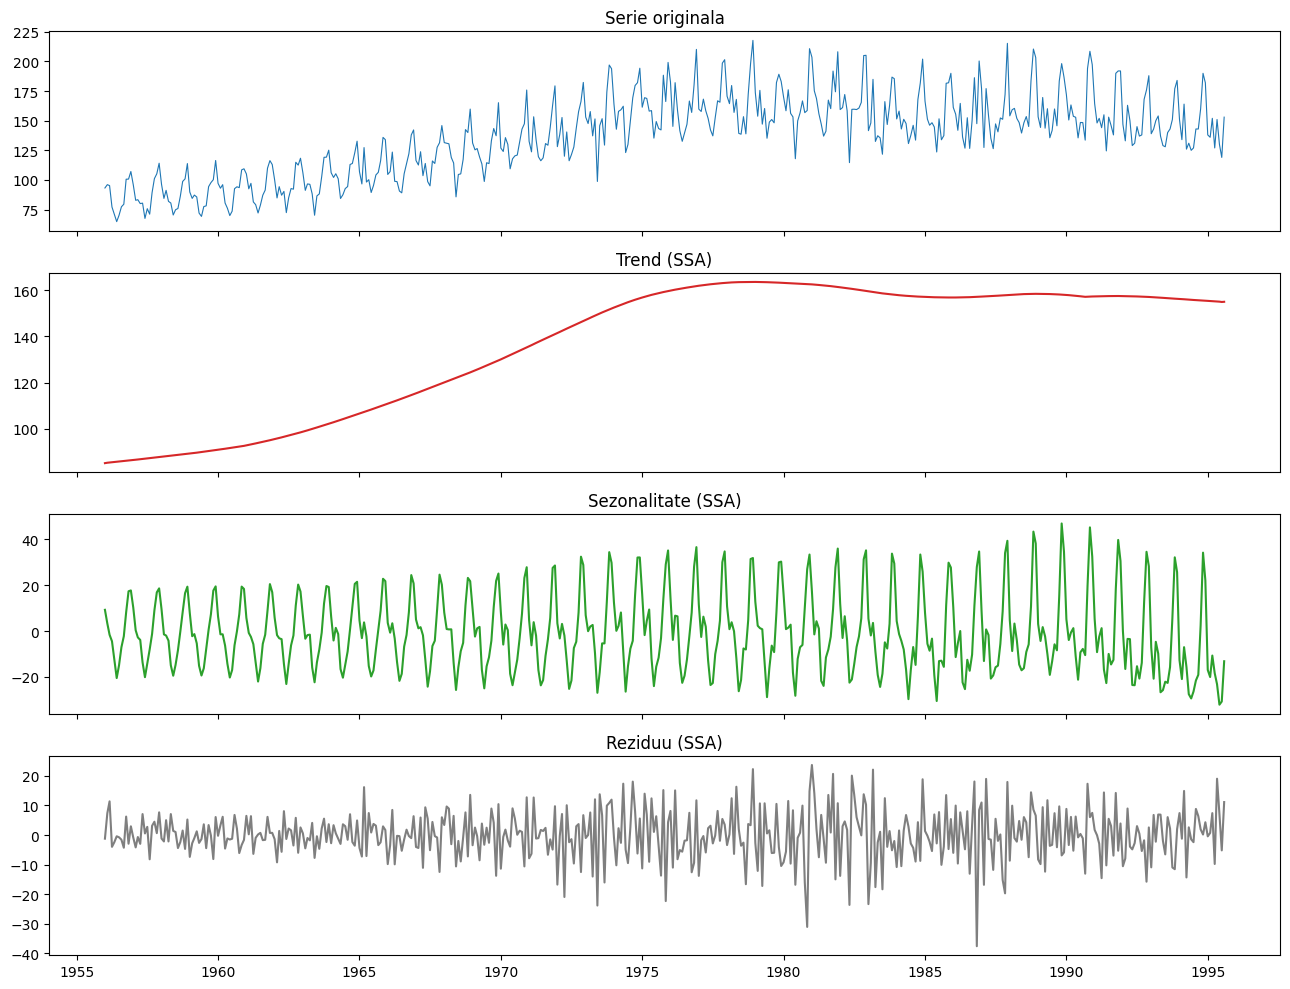

In [40]:
grupuri = [
    [0],                                      # trend
    [1, 2, 3, 4, 5, 6, 7, 8],                 # sezonalitate
    list(range(9, componente.shape[0])),      # reziduu / zgomot
]
ssa_grup = SingularSpectrumAnalysis(window_size=L, groups=grupuri)
trend_ssa, sezon_ssa, zgomot_ssa = ssa_grup.fit_transform(X)[0]

idx = beer.index
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(idx, serie, lw=0.8);            axes[0].set_title('Serie originala')
axes[1].plot(idx, trend_ssa, color='tab:red');   axes[1].set_title('Trend (SSA)')
axes[2].plot(idx, sezon_ssa, color='tab:green'); axes[2].set_title('Sezonalitate (SSA)')
axes[3].plot(idx, zgomot_ssa, color='tab:gray'); axes[3].set_title('Reziduu (SSA)')
plt.tight_layout(); plt.show()